In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score
)

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge"

TRAIN_AUDIO_PATH = os.path.join(DATASET_PATH, "train")
FEATURE_DIR = os.path.join(DATASET_PATH, "processed_features")

In [4]:
print("Dataset path:", DATASET_PATH)
print("Audio path:", TRAIN_AUDIO_PATH)
print("Feature path:", FEATURE_DIR)

Dataset path: /content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge
Audio path: /content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge/train
Feature path: /content/drive/MyDrive/bio-cas-2024-depression-detection-grand-challenge/processed_features


In [ ]:
train_df = pd.read_csv(
    os.path.join(DATASET_PATH, "Train.csv")
)

X_mfcc = np.load(
    os.path.join(FEATURE_DIR, "X_mfcc.npy")
)

y = np.load(
    os.path.join(FEATURE_DIR, "y.npy")
)

print("Train dataframe shape:", train_df.shape)
print("MFCC feature shape:", X_mfcc.shape)
print("Target shape:", y.shape)

Train dataframe shape: (89, 7)
MFCC feature shape: (89, 26)
Target shape: (89,)


In [ ]:
unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Label {label}: {count} samples")

Label 0: 41 samples
Label 1: 7 samples
Label 2: 26 samples
Label 3: 15 samples


In [ ]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        class_weight="balanced"
    ))
])

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
y_pred = cross_val_predict(
    svm_model,
    X_mfcc,
    y,
    cv=cv
)

In [ ]:
macro_f1 = f1_score(
    y,
    y_pred,
    average="macro"
)

balanced_acc = balanced_accuracy_score(
    y,
    y_pred
)

print("Macro F1:", round(macro_f1, 4))
print("Balanced Accuracy:", round(balanced_acc, 4))

Macro F1: 0.3529
Balanced Accuracy: 0.3518


In [ ]:
print("\nClassification Report:\n")

print(
    classification_report(
        y,
        y_pred,
        digits=4
    )
)


Classification Report:

              precision    recall  f1-score   support

           0     0.8286    0.7073    0.7632        41
           1     0.0000    0.0000    0.0000         7
           2     0.3714    0.5000    0.4262        26
           3     0.2500    0.2000    0.2222        15

    accuracy                         0.5056        89
   macro avg     0.3625    0.3518    0.3529        89
weighted avg     0.5323    0.5056    0.5135        89



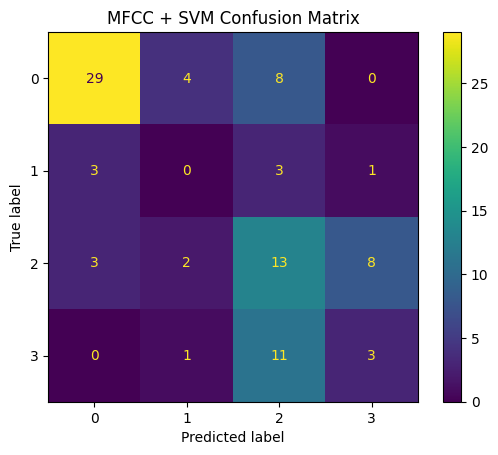

In [ ]:
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("MFCC + SVM Confusion Matrix")
plt.show()

Using CNN

In [ ]:
TARGET_SR = 16000

SEGMENT_DURATION = 5        # seconds
SEGMENT_SAMPLES = TARGET_SR * SEGMENT_DURATION

N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256

In [ ]:
def audio_to_logmel(audio_segment, sr=16000):

    mel = librosa.feature.melspectrogram(
        y=audio_segment,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    log_mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return log_mel

In [ ]:
TRAIN_AUDIO_PATH = os.path.join(DATASET_PATH, "train")

train_df["audio_path"] = train_df["File_name"].apply(
    lambda x: os.path.join(TRAIN_AUDIO_PATH, x)
)

In [ ]:
print(train_df[["Participant", "File_name", "audio_path"]].head())

  Participant File_name                                         audio_path
0        S026  S026.mp3  /content/drive/MyDrive/bio-cas-2024-depression...
1        S055  S055.mp3  /content/drive/MyDrive/bio-cas-2024-depression...
2        S029  S029.mp3  /content/drive/MyDrive/bio-cas-2024-depression...
3        S089  S089.mp3  /content/drive/MyDrive/bio-cas-2024-depression...
4        S005  S005.mp3  /content/drive/MyDrive/bio-cas-2024-depression...


In [ ]:
sample_path = train_df.iloc[0]["audio_path"]

audio, sr = librosa.load(
    sample_path,
    sr=TARGET_SR,
    mono=True
)

print("Sampling rate:", sr)
print("Audio duration:", round(len(audio) / sr, 2), "seconds")

/tmp/ipykernel_3282/1522933186.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sampling rate: 16000
Audio duration: 439.79 seconds


In [ ]:
sample_segment = audio[:SEGMENT_SAMPLES]

log_mel = audio_to_logmel(sample_segment)

print("Log-Mel shape:", log_mel.shape)

Log-Mel shape: (64, 313)


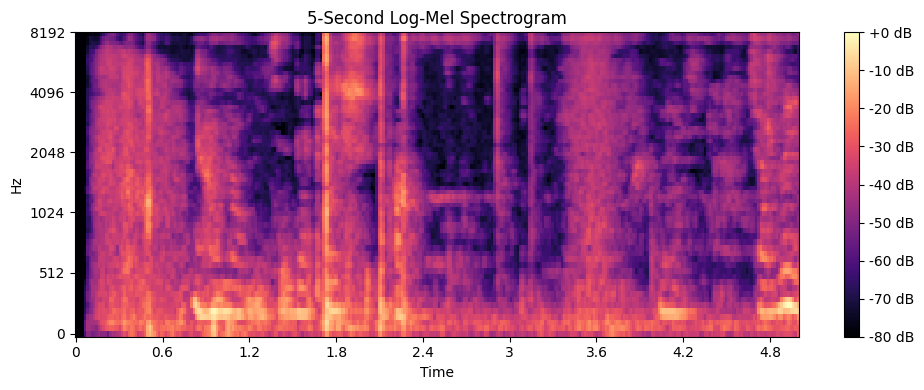

In [ ]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    log_mel,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("5-Second Log-Mel Spectrogram")
plt.tight_layout()
plt.show()

In [ ]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_indices, val_indices = next(
    skf.split(train_df, train_df["Label"])
)

train_participants = train_df.iloc[train_indices].copy()
val_participants = train_df.iloc[val_indices].copy()

print("Training participants:", len(train_participants))
print("Validation participants:", len(val_participants))

Training participants: 71
Validation participants: 18


In [ ]:
def create_audio_segments(
    audio_path,
    sr=16000,
    segment_duration=5
):

    audio, _ = librosa.load(
        audio_path,
        sr=sr,
        mono=True
    )

    segment_samples = sr * segment_duration

    segments = []

    for start in range(
        0,
        len(audio) - segment_samples + 1,
        segment_samples
    ):

        segment = audio[start:start + segment_samples]

        segments.append(segment)

    return segments

In [ ]:
segments = create_audio_segments(sample_path)

print("Number of 5-second segments:", len(segments))
print("Shape of first segment:", segments[0].shape)

/tmp/ipykernel_3282/3514634109.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Number of 5-second segments: 87
Shape of first segment: (80000,)


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [13]:
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

PyTorch version: 2.11.0+cu128
GPU available: True
Using device: cuda


In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="PySoundFile failed. Trying audioread instead."
)

warnings.filterwarnings(
    "ignore",
    message=".*audioread.*Deprecated.*"
)

In [10]:
class SpeechDataset(Dataset):

    def __init__(
        self,
        dataframe,
        sr=16000,
        segment_duration=5
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.sr = sr
        self.segment_duration = segment_duration
        self.segment_samples = sr * segment_duration

        self.segments = []

        print("Preparing dataset...")

        for idx, row in self.dataframe.iterrows():

            audio_path = row["audio_path"]
            label = int(row["Label"])
            participant = row["Participant"]

            # Load each audio file ONCE
            audio, _ = librosa.load(
                audio_path,
                sr=sr,
                mono=True
            )

            num_segments = len(audio) // self.segment_samples

            for segment_idx in range(num_segments):

                start = segment_idx * self.segment_samples
                end = start + self.segment_samples

                segment = audio[start:end]

                # Create Log-Mel once
                log_mel = audio_to_logmel(
                    segment,
                    sr=sr
                )

                self.segments.append({
                    "participant": participant,
                    "label": label,
                    "log_mel": log_mel
                })

        print(
            f"Participants: {len(self.dataframe)} | "
            f"Segments: {len(self.segments)}"
        )

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, index):

        item = self.segments[index]

        log_mel = torch.tensor(
            item["log_mel"],
            dtype=torch.float32
        )

        # [64, 313] → [1, 64, 313]
        log_mel = log_mel.unsqueeze(0)

        label = torch.tensor(
            item["label"],
            dtype=torch.long
        )
        participants = item["participant"]
        return log_mel, label,participants

In [ ]:
train_dataset = SpeechDataset(
    train_participants
)

val_dataset = SpeechDataset(
    val_participants
)

Preparing dataset...


/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa ve

Participants: 71 | Segments: 5307
Preparing dataset...


/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa ve

Participants: 18 | Segments: 1203


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

In [ ]:
X_batch, y_batch, participants = next(iter(train_loader))

print("Input shape:", X_batch.shape)
print("Label shape:", y_batch.shape)
print("Labels:", y_batch)
print("First 5 participants:", participants[:5])

Input shape: torch.Size([16, 1, 64, 313])
Label shape: torch.Size([16])
Labels: tensor([2, 2, 2, 1, 2, 0, 2, 2, 0, 2, 2, 3, 2, 0, 3, 2])
First 5 participants: ('S063', 'S035', 'S034', 'S011', 'S026')


In [11]:
class SpeechCNN(nn.Module):

    def __init__(self, num_classes=4):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [ ]:
model = SpeechCNN(num_classes=4)

model = model.to(device)

print(model)

SpeechCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=6

In [ ]:
X_batch = X_batch.to(device)

with torch.no_grad():
    output = model(X_batch)

print("Input shape:", X_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([16, 1, 64, 313])
Output shape: torch.Size([16, 4])


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(
    train_participants["Label"]
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_participants["Label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Classes:", classes)
print("Class weights:", class_weights)

Classes: [0 1 2 3]
Class weights: tensor([0.5379, 2.9583, 0.8875, 1.4792], device='cuda:0')


In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X, y_batch, _ in loader:

        X = X.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X)

        # Calculate loss
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Track loss
        running_loss += loss.item() * X.size(0)

        # Predictions
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
def evaluate_participant_level(
    model,
    loader,
    device
):

    model.eval()

    participant_probs = {}
    participant_labels = {}

    with torch.no_grad():

        for X, y_batch, participants in loader:

            X = X.to(device)

            outputs = model(X)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            probs = probs.cpu().numpy()
            y_batch = y_batch.numpy()

            # Store predictions for each participant
            for prob, label, participant in zip(
                probs,
                y_batch,
                participants
            ):

                if participant not in participant_probs:
                    participant_probs[participant] = []

                participant_probs[participant].append(prob)

                participant_labels[participant] = int(label)

    # Convert segment predictions → participant predictions
    y_true = []
    y_pred = []

    for participant in participant_probs:

        avg_prob = np.mean(
            participant_probs[participant],
            axis=0
        )

        prediction = np.argmax(avg_prob)

        y_true.append(
            participant_labels[participant]
        )

        y_pred.append(prediction)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    return (
        macro_f1,
        balanced_acc,
        y_true,
        y_pred
    )

In [ ]:
import time

start_time = time.time()

X_batch, y_batch = next(iter(train_loader))

end_time = time.time()

print("Batch shape:", X_batch.shape)
print("Time to load batch:", round(end_time - start_time, 2), "seconds")

Batch shape: torch.Size([16, 1, 64, 313])
Time to load batch: 0.27 seconds


In [ ]:
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

start_time = time.time()

with torch.no_grad():
    output = model(X_batch)

end_time = time.time()

print("Output shape:", output.shape)
print("Model inference time:", round(end_time - start_time, 2), "seconds")

Output shape: torch.Size([16, 4])
Model inference time: 0.0 seconds


In [ ]:
NUM_EPOCHS = 10

train_losses = []
train_accuracies = []

val_macro_f1s = []
val_balanced_accs = []

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_f1, val_balanced_acc, _, _ = evaluate_participant_level(
        model,
        val_loader,

        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_macro_f1s.append(val_f1)
    val_balanced_accs.append(val_balanced_acc)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Macro F1: {val_f1:.4f} | "
        f"Val Balanced Acc: {val_balanced_acc:.4f}"
    )

Epoch [1/10] | Loss: 1.1822 | Train Acc: 0.4590 | Val Macro F1: 0.1250 | Val Balanced Acc: 0.2083
Epoch [2/10] | Loss: 1.1015 | Train Acc: 0.5221 | Val Macro F1: 0.1875 | Val Balanced Acc: 0.2440
Epoch [3/10] | Loss: 1.0410 | Train Acc: 0.5423 | Val Macro F1: 0.3324 | Val Balanced Acc: 0.3512
Epoch [4/10] | Loss: 0.9676 | Train Acc: 0.5847 | Val Macro F1: 0.1325 | Val Balanced Acc: 0.1190
Epoch [5/10] | Loss: 0.9152 | Train Acc: 0.6145 | Val Macro F1: 0.1414 | Val Balanced Acc: 0.2857
Epoch [6/10] | Loss: 0.8867 | Train Acc: 0.6329 | Val Macro F1: 0.2242 | Val Balanced Acc: 0.2381
Epoch [7/10] | Loss: 0.8221 | Train Acc: 0.6604 | Val Macro F1: 0.3598 | Val Balanced Acc: 0.3810
Epoch [8/10] | Loss: 0.8122 | Train Acc: 0.6702 | Val Macro F1: 0.3625 | Val Balanced Acc: 0.4226
Epoch [9/10] | Loss: 0.7430 | Train Acc: 0.6842 | Val Macro F1: 0.2872 | Val Balanced Acc: 0.3095
Epoch [10/10] | Loss: 0.7263 | Train Acc: 0.7027 | Val Macro F1: 0.3333 | Val Balanced Acc: 0.3750


In [ ]:
best_epoch = np.argmax(val_macro_f1s)

print("Best CNN epoch:", best_epoch + 1)
print("Best CNN Macro F1:", val_macro_f1s[best_epoch])
print("Best CNN Balanced Accuracy:", val_balanced_accs[best_epoch])

Best CNN epoch: 8
Best CNN Macro F1: 0.36250000000000004
Best CNN Balanced Accuracy: 0.42261904761904756


In [ ]:
torch.save(
    model.state_dict(),
    os.path.join(
        FEATURE_DIR,
        "cnn_best_depression.pth"
    )
)

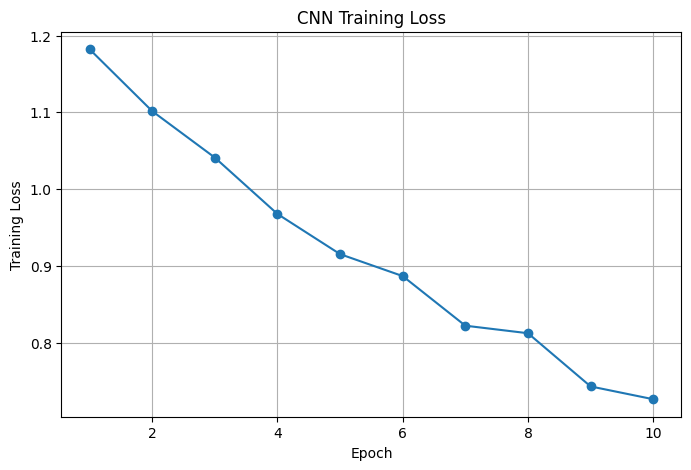

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")
plt.grid(True)

plt.show()

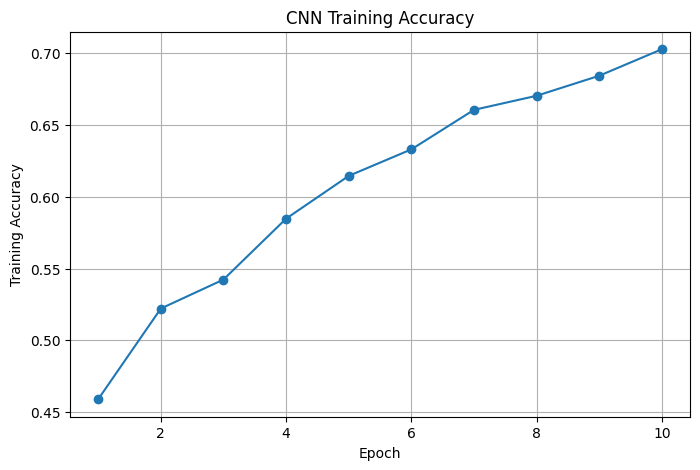

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("CNN Training Accuracy")
plt.grid(True)

plt.show()

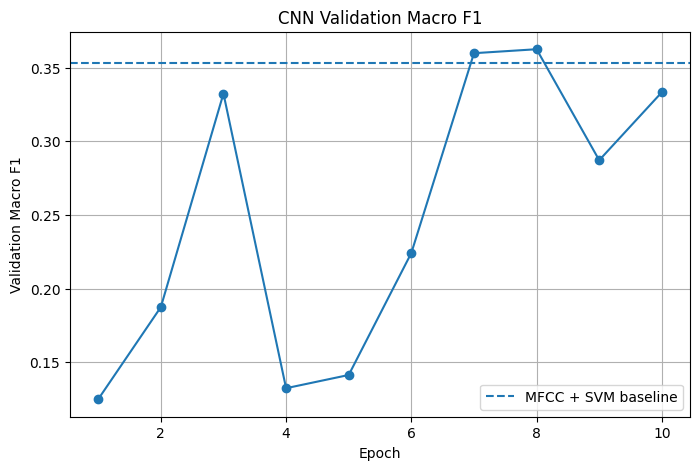

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_macro_f1s,
    marker="o"
)

plt.axhline(
    y=0.3529,
    linestyle="--",
    label="MFCC + SVM baseline"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title("CNN Validation Macro F1")
plt.legend()
plt.grid(True)

plt.show()

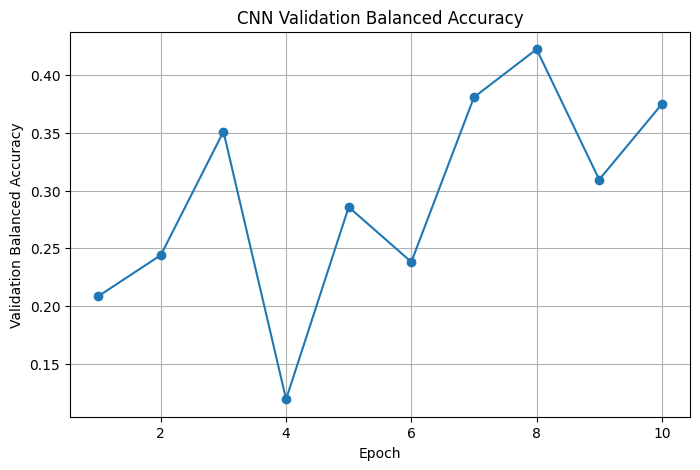

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_balanced_accs,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Balanced Accuracy")
plt.title("CNN Validation Balanced Accuracy")
plt.grid(True)

plt.show()

In [ ]:
# Load the previously saved CNN model

model = SpeechCNN(num_classes=4).to(device)

model_path = os.path.join(
    FEATURE_DIR,
    "cnn_best_depression.pth"
)

model.load_state_dict(torch.load(model_path, map_location=device))

print("CNN model loaded successfully.")

CNN model loaded successfully.


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
NUM_EPOCHS = 20
patience = 5

best_val_f1 = 0.3625
patience_counter = 0

train_losses = []
train_accuracies = []
val_macro_f1s = []
val_balanced_accs = []

best_model_path = os.path.join(
    FEATURE_DIR,
    "cnn_best_depression.pth"
)

for epoch in range(NUM_EPOCHS):


    # Training

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )


    # Validation

    val_f1, val_balanced_acc, _, _ = evaluate_participant_level(
        model,
        val_loader,
        device
    )

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_macro_f1s.append(val_f1)
    val_balanced_accs.append(val_balanced_acc)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Macro F1: {val_f1:.4f} | "
        f"Val Balanced Acc: {val_balanced_acc:.4f}"
    )


    # Save Best Model

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print(
            f"   New best model saved! "
            f"Val Macro F1 = {best_val_f1:.4f}"
        )

    else:

        patience_counter += 1

        print(
            f"  No improvement "
            f"({patience_counter}/{patience})"
        )


    # Early Stopping

    if patience_counter >= patience:

        print("\nEarly stopping triggered.")
        print(
            f"Best Validation Macro F1: "
            f"{best_val_f1:.4f}"
        )

        break

Epoch [1/20] | Loss: 0.4965 | Train Acc: 0.7933 | Val Macro F1: 0.3250 | Val Balanced Acc: 0.3750
  No improvement (1/5)
Epoch [2/20] | Loss: 0.4762 | Train Acc: 0.7997 | Val Macro F1: 0.1989 | Val Balanced Acc: 0.2857
  No improvement (2/5)
Epoch [3/20] | Loss: 0.4651 | Train Acc: 0.8078 | Val Macro F1: 0.3688 | Val Balanced Acc: 0.4286
   New best model saved! Val Macro F1 = 0.3688
Epoch [4/20] | Loss: 0.4554 | Train Acc: 0.8093 | Val Macro F1: 0.3943 | Val Balanced Acc: 0.4286
   New best model saved! Val Macro F1 = 0.3943
Epoch [5/20] | Loss: 0.4500 | Train Acc: 0.8110 | Val Macro F1: 0.2500 | Val Balanced Acc: 0.2798
  No improvement (1/5)
Epoch [6/20] | Loss: 0.4237 | Train Acc: 0.8259 | Val Macro F1: 0.4208 | Val Balanced Acc: 0.4405
   New best model saved! Val Macro F1 = 0.4208
Epoch [7/20] | Loss: 0.4226 | Train Acc: 0.8240 | Val Macro F1: 0.4239 | Val Balanced Acc: 0.4226
   New best model saved! Val Macro F1 = 0.4239
Epoch [8/20] | Loss: 0.3997 | Train Acc: 0.8363 | Val Mac

In [ ]:
# Loading the best CNN checkpoint

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

print("Best CNN model loaded.")
print(f"Best Validation Macro F1: {best_val_f1:.4f}")

Best CNN model loaded.
Best Validation Macro F1: 0.4762


In [ ]:
best_f1, best_balanced_acc, y_true, y_pred = evaluate_participant_level(
    model,
    val_loader,
    device
)

print("Best Model Results")
print("------------------")
print(f"Macro F1: {best_f1:.4f}")
print(f"Balanced Accuracy: {best_balanced_acc:.4f}")

Best Model Results
------------------
Macro F1: 0.4762
Balanced Accuracy: 0.4286


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    0.7143    0.8333         7
           1     0.0000    0.0000    0.0000         1
           2     0.5000    0.6667    0.5714         6
           3     1.0000    0.3333    0.5000         3

    accuracy                         0.5882        17
   macro avg     0.6250    0.4286    0.4762        17
weighted avg     0.7647    0.5882    0.6331        17



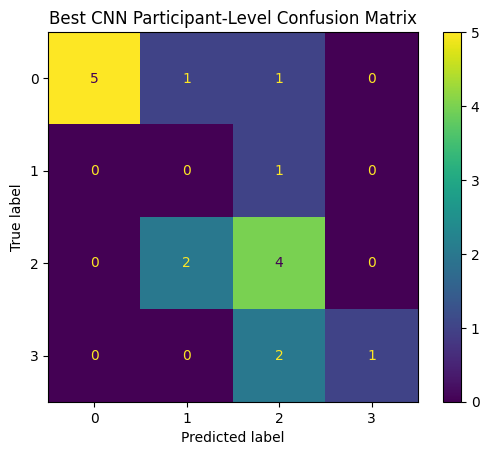

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3]
)

disp.plot()
plt.title("Best CNN Participant-Level Confusion Matrix")
plt.show()

In [ ]:
print("Number of validation participants:", len(val_participants))
print("Number evaluated:", len(y_true))

print("\nValidation label distribution:")
print(val_participants["Label"].value_counts().sort_index())

print("\nEvaluated label distribution:")
print(pd.Series(y_true).value_counts().sort_index())

Number of validation participants: 18
Number evaluated: 17

Validation label distribution:
Label
0    8
1    1
2    6
3    3
Name: count, dtype: int64

Evaluated label distribution:
0    7
1    1
2    6
3    3
Name: count, dtype: int64


In [ ]:
evaluated_participants = set()

model.eval()

with torch.no_grad():
    for X, y_batch, participants in val_loader:
        X = X.to(device)

        outputs = model(X)

        for participant in participants:
            evaluated_participants.add(participant)

all_val_participants = set(val_participants["Participant"])

missing_participants = all_val_participants - evaluated_participants

print("Missing validation participant(s):")
print(missing_participants)

Missing validation participant(s):
{'S089'}


In [ ]:
print(
    val_participants[
        val_participants["Participant"].isin(missing_participants)
    ][["Participant", "File_name", "Label", "audio_path"]]
)

  Participant File_name  Label  \
3        S089  S089.mp3      0   

                                          audio_path  
3  /content/drive/MyDrive/bio-cas-2024-depression...  


In [ ]:
s089_path = os.path.join(TRAIN_AUDIO_PATH, "S089.mp3")

audio, sr = librosa.load(
    s089_path,
    sr=16000,
    mono=True
)

duration = len(audio) / sr

print("Sampling Rate:", sr)
print("Number of samples:", len(audio))
print("Duration:", duration, "seconds")
print("5-second segments:", len(audio) // SEGMENT_SAMPLES)

Sampling Rate: 16000
Number of samples: 3344
Duration: 0.209 seconds
5-second segments: 0


#One validation recording (S089) contained only 0.209 seconds of audio, which was shorter than the 5-second segment duration and therefore produced no valid segment. It was excluded from participant-level CNN evaluation due to insufficient speech duration.

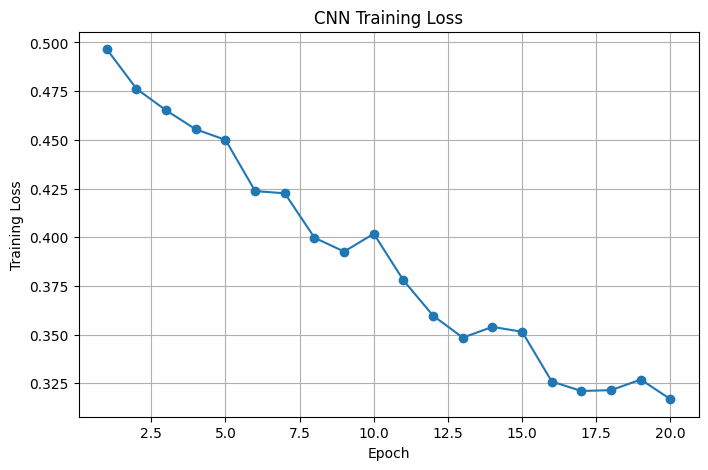

In [ ]:
epochs_completed = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")
plt.grid(True)
plt.show()

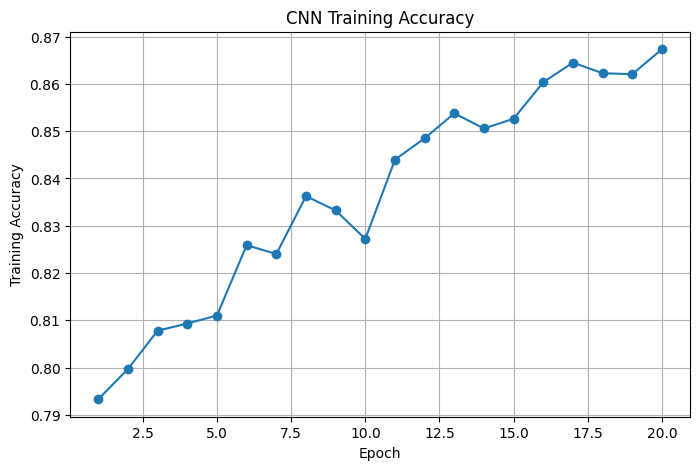

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("CNN Training Accuracy")
plt.grid(True)
plt.show()

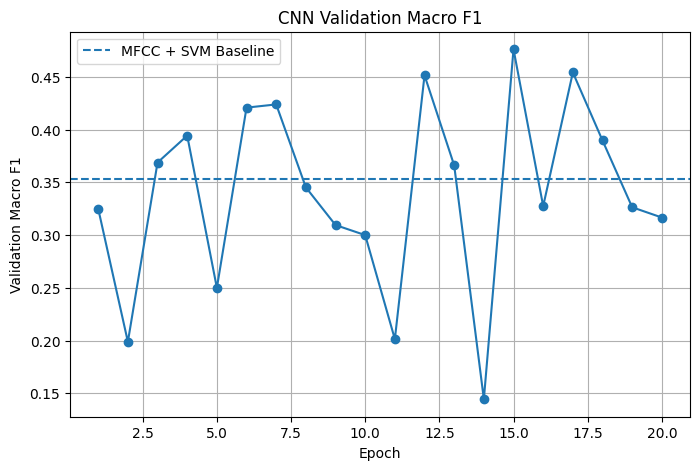

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, val_macro_f1s, marker="o")
plt.axhline(
    y=0.3529,
    linestyle="--",
    label="MFCC + SVM Baseline"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.title("CNN Validation Macro F1")
plt.legend()
plt.grid(True)
plt.show()



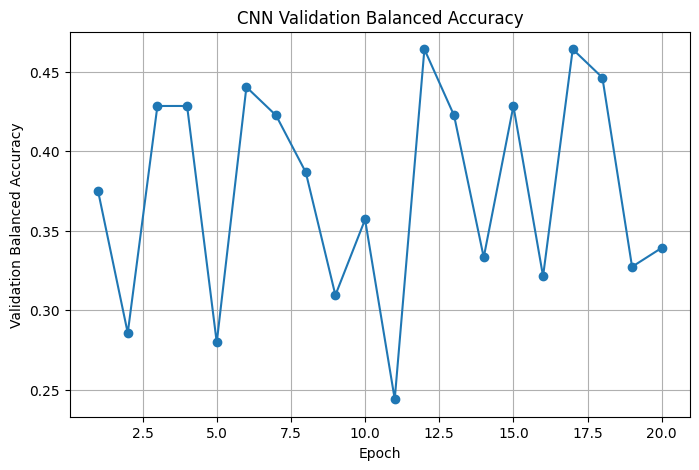

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_completed, val_balanced_accs, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Balanced Accuracy")
plt.title("CNN Validation Balanced Accuracy")
plt.grid(True)
plt.show()

## Conclusion

The MFCC + SVM baseline achieved a validation Macro F1 of 0.3529
and Balanced Accuracy of 0.3518.

The Log-Mel spectrogram based CNN achieved a higher validation
Macro F1 of 0.4762 and Balanced Accuracy of 0.4286.

These results indicate that the CNN-based representation was more
effective than the classical MFCC + SVM baseline on the evaluated
validation participants.

However, the dataset is small and imbalanced, and one validation
recording (S089) contained only approximately 0.209 seconds of audio.
Therefore, the results should be considered preliminary and should
not be interpreted as clinical-level performance.

The next stage is to investigate pretrained speech representations
such as Wav2Vec2 or WavLM to determine whether learned speech
representations can provide further improvements.